In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    chi2_contingency, pearsonr, spearmanr,
    normaltest, jarque_bera
)
from numpy.polynomial.polynomial import polyfit, polyval
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

df = pd.read_csv('insurance.csv', encoding='latin1')


print('Размер:', df.shape)
print(df.columns.tolist())
df.head()

from scipy.stats import chisquare, norm


def fmt_p(p):
    """p-value печатается честно: ниже ~1e-308 double обнуляется, это не настоящий ноль."""
    if not np.isfinite(p):
        return 'н/д'
    if p < 1e-300:
        return '< 1e-300'
    return f'{p:.4e}'


def resid_mean_note(resid):
    """Среднее остатков МНК равно нулю с точностью до округления; показываем масштаб."""
    m = resid.mean()
    scale = np.abs(resid).mean()
    return f'{m:.3e} (при среднем |остатке| {scale:.3f}, т.е. ноль с точностью машинного округления)'


Размер: (1338, 7)
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [27]:
print('Типы данных:')
print(df.dtypes)
print('\nПропуски:')
print(df.isnull().sum())
print('\nКатегориальные:')
print('sex:', df['sex'].unique())
print('smoker:', df['smoker'].unique())
print('region:', df['region'].unique())

Типы данных:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Пропуски:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Категориальные:
sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [28]:
num_vars = ['age', 'bmi', 'children', 'charges']

desc = df[num_vars].describe().T
desc['median'] = df[num_vars].median()
desc['skew'] = df[num_vars].skew()
desc['kurtosis'] = df[num_vars].kurtosis()
desc['mode'] = df[num_vars].mode().iloc[0]

print('Дескриптивная статистика')
display(desc.round(3))

Дескриптивная статистика


,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis,mode
age,1338.0,39.207,14.050,18.000,27.000,39.000,51.000,64.000,39.000,0.056,-1.245,18.000
bmi,1338.0,30.663,6.098,15.960,26.296,30.400,34.694,53.130,30.400,0.284,-0.051,32.300
children,1338.0,1.095,1.205,0.000,0.000,1.000,2.000,5.000,1.000,0.938,0.202,0.000
charges,1338.0,13270.422,12110.011,1121.874,4740.287,9382.033,16639.913,63770.428,9382.033,1.516,1.606,1639.563


In [29]:
from scipy.stats import normaltest, jarque_bera, chisquare, norm
import numpy as np

def normality_report(series, name, alpha=0.05):
    n = len(series)
    k2, p_dag = normaltest(series)
    jb, p_jb = jarque_bera(series)
    skew = series.skew()
    kurt = series.kurtosis()

    # Критерий согласия Пирсона. μ и σ оценены по выборке, поэтому ddof=2:
    # df = k − 1 − 2. Интервалы с E < 5 объединяются.
    k = int(np.ceil(1 + 3.322 * np.log10(n)))
    counts, bin_edges = np.histogram(series, bins=k)

    mu, sigma = series.mean(), series.std(ddof=1)
    expected = np.array([
        (norm.cdf(bin_edges[i + 1], mu, sigma) - norm.cdf(bin_edges[i], mu, sigma)) * n
        for i in range(len(bin_edges) - 1)
    ])

    counts = counts.astype(float).tolist()
    expected = expected.tolist()
    i = 0
    while i < len(expected):
        if expected[i] < 5 and len(expected) > 1:
            j = i - 1 if i == len(expected) - 1 else i + 1
            a, b = (i, j) if i < j else (j, i)
            counts[a] += counts[b]
            expected[a] += expected[b]
            del counts[b], expected[b]
            i = 0
        else:
            i += 1
    counts = np.array(counts)
    expected = np.array(expected)
    expected = expected * counts.sum() / expected.sum()

    k_bins = len(counts)
    df_chi = k_bins - 1 - 2
    if df_chi < 1:
        chi2_stat, p_chi2 = np.nan, np.nan
        chi_line = f'Пирсон χ²: осталось {k_bins} интервалов, df = k − p − 1 < 1, тест не применяется'
    else:
        chi2_stat, p_chi2 = chisquare(counts, f_exp=expected, ddof=2)
        chi_line = (f'Пирсон χ²:       stat={chi2_stat:.3f}, '
                    f'df = k − p − 1 = {k_bins} − 2 − 1 = {df_chi}, p={fmt_p(p_chi2)}')

    print(f'\n--- {name} (n={n}) ---')
    print(f'Среднее: {series.mean():.3f}, Медиана: {series.median():.3f}, Мода: {series.mode().iloc[0]:.3f}')
    print(f'Асимметрия (skew): {skew:.3f}')
    print(f'Эксцесс (kurtosis): {kurt:.3f}')
    print(f"D'Agostino K²:   stat={k2:.3f}, p={fmt_p(p_dag)}")
    print(f'Jarque-Bera:     stat={jb:.3f}, p={fmt_p(p_jb)}')
    print(chi_line)

    chi_ok = np.isnan(p_chi2) or p_chi2 > alpha
    if (p_dag > alpha and p_jb > alpha and chi_ok
        and abs(skew) < 0.5 and abs(kurt) < 1):
        print('СОГЛАСУЕТСЯ с нормальным распределением')
        return True
    else:
        print('НЕ согласуется с нормальным распределением')
        return False

for col in ['age', 'bmi', 'children', 'charges']:
    normality_report(df[col], col)


--- age (n=1338) ---
Среднее: 39.207, Медиана: 39.000, Мода: 18.000
Асимметрия (skew): 0.056
Эксцесс (kurtosis): -1.245
D'Agostino K²:   stat=1557.821, p=< 1e-300
Jarque-Bera:     stat=87.093, p=1.2249e-19
Пирсон χ²:       stat=438.563, df = k − p − 1 = 12 − 2 − 1 = 9, p=7.9794e-89
НЕ согласуется с нормальным распределением

--- bmi (n=1338) ---
Среднее: 30.663, Медиана: 30.400, Мода: 32.300
Асимметрия (skew): 0.284
Эксцесс (kurtosis): -0.051
D'Agostino K²:   stat=17.581, p=1.5214e-04
Jarque-Bera:     stat=18.121, p=1.1618e-04
Пирсон χ²:       stat=10.043, df = k − p − 1 = 10 − 2 − 1 = 7, p=1.8613e-01
НЕ согласуется с нормальным распределением

--- children (n=1338) ---
Среднее: 1.095, Медиана: 1.000, Мода: 0.000
Асимметрия (skew): 0.938
Эксцесс (kurtosis): 0.202
D'Agostino K²:   stat=147.700, p=8.4579e-33
Jarque-Bera:     stat=198.093, p=9.6546e-44
Пирсон χ²:       stat=1896.703, df = k − p − 1 = 11 − 2 − 1 = 8, p=< 1e-300
НЕ согласуется с нормальным распределением

--- charges (n=13

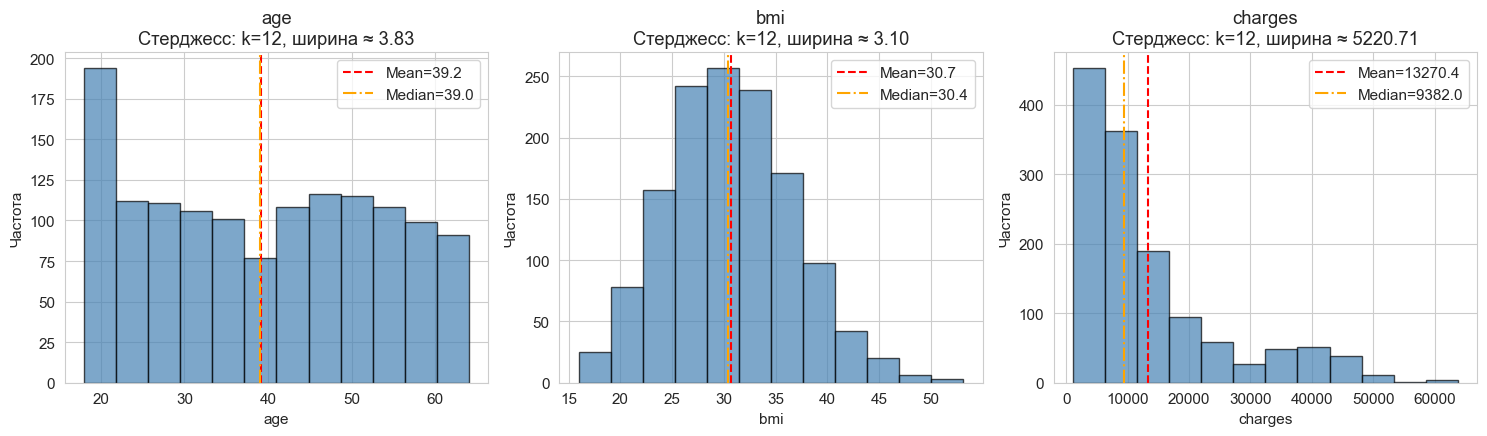

In [30]:
def sturges_bins(series):
    """k = 1 + 3.322 * log10(n)"""
    n = len(series)
    k = int(np.ceil(1 + 3.322 * np.log10(n)))
    return k

vars_for_hist = ['age', 'bmi', 'charges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col in zip(axes, vars_for_hist):
    k = sturges_bins(df[col])
    data_min, data_max = df[col].min(), df[col].max()
    bin_width = (data_max - data_min) / k

    ax.hist(df[col], bins=k, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'{col}\nСтерджесс: k={k}, ширина ≈ {bin_width:.2f}')
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')
    ax.axvline(df[col].mean(), color='red', linestyle='--',
               label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-.',
               label=f'Median={df[col].median():.1f}')
    ax.legend()

plt.tight_layout()
plt.show()


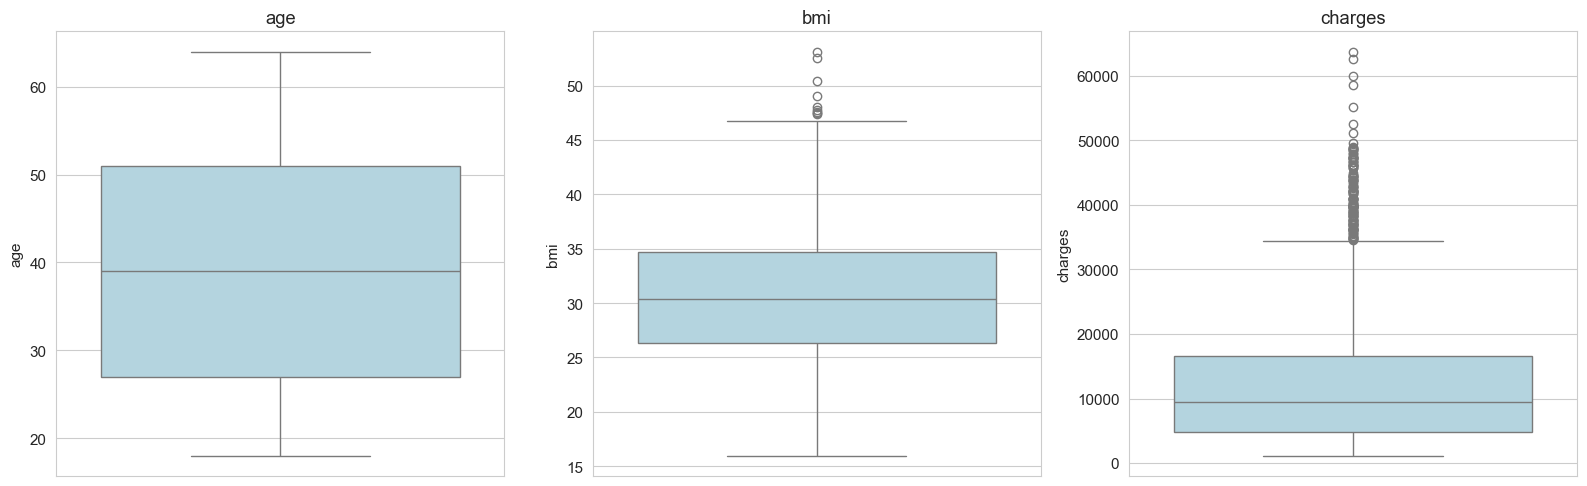

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, vars_for_hist):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [32]:
df['Children_cat'] = pd.cut(
    df['children'],
    bins=[-0.1, 0, 2, 10],          # 0 | 1-2 | 3+
    labels=['No', '1-2', 'Many']
)

print(df['Children_cat'].value_counts().sort_index())

Children_cat
No      574
1-2     564
Many    200
Name: count, dtype: int64


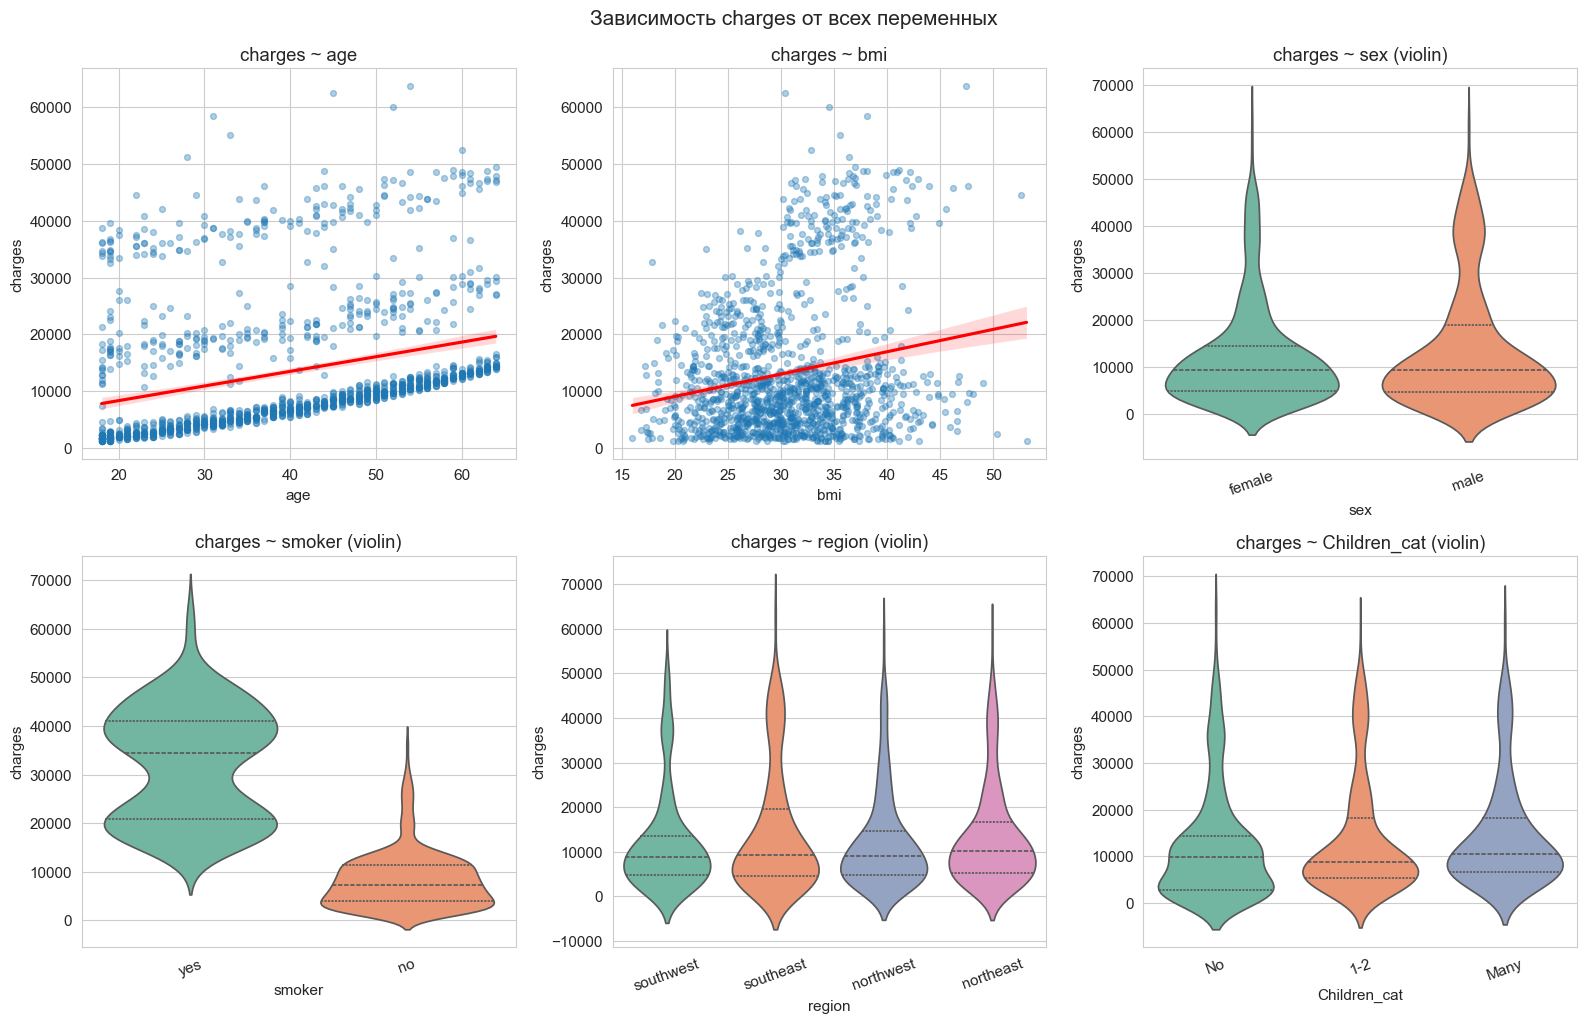

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

num_vars = ['age', 'bmi']
cat_vars = ['sex', 'smoker', 'region', 'Children_cat']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# 1. Числовые — scatter + линия тренда
for i, col in enumerate(num_vars):
    sns.regplot(
        data=df, x=col, y='charges',
        ax=axes[i],
        scatter_kws={'alpha': 0.35, 's': 18},
        line_kws={'color': 'red'}
    )
    axes[i].set_title(f'charges ~ {col}')

# 2. Категориальные — violin plot (форма распределения)
for i, col in enumerate(cat_vars):
    sns.violinplot(
        data=df, x=col, y='charges',
        ax=axes[i + len(num_vars)],
        palette='Set2',
        inner='quartile'          # показывает квартили внутри
    )
    axes[i + len(num_vars)].set_title(f'charges ~ {col} (violin)')
    axes[i + len(num_vars)].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.suptitle('Зависимость charges от всех переменных', y=1.02, fontsize=15)
plt.show()

In [34]:
# Зависимая переменная — charges (расходы на страховку).
# Независимые: age, bmi, children (количественные), sex, smoker, region (номинальные).
df['Charges_cat'] = pd.qcut(df['charges'], q=3, labels=['Low', 'Medium', 'High'])
print('Charges_cat:')
print(df['Charges_cat'].value_counts().sort_index())

def contingency_test(row, col, title):
    print(f'\n=== {title} ===')
    display(pd.crosstab(df[row], df[col], margins=True))
    observed = pd.crosstab(df[row], df[col])
    chi2, p, dof, expected = chi2_contingency(observed)
    r, c = observed.shape
    print(f'χ² = {chi2:.3f}, df = (r−1)(c−1) = ({r}−1)({c}−1) = {dof}, p = {fmt_p(p)}')
    print('Ожидаемые частоты:')
    display(pd.DataFrame(expected, index=observed.index, columns=observed.columns).round(1))
    if p < 0.05:
        print('H0 о независимости отвергается: зависимость значима')
    else:
        print('H0 о независимости не отвергается')

contingency_test('smoker', 'Charges_cat', 'Курение × уровень расходов')
contingency_test('sex', 'Charges_cat', 'Пол × уровень расходов')
contingency_test('region', 'Charges_cat', 'Регион × уровень расходов')
contingency_test('Children_cat', 'Charges_cat', 'Число детей × уровень расходов')


Charges_cat:
Charges_cat
Low       446
Medium    446
High      446
Name: count, dtype: int64

=== Курение × уровень расходов ===


Charges_cat,Low,Medium,High,All
smoker,,,,
no,446,446,172,1064
yes,0,0,274,274
All,446,446,446,1338


χ² = 689.120, df = (r−1)(c−1) = (2−1)(3−1) = 2, p = 2.2879e-150
Ожидаемые частоты:


Charges_cat,Low,Medium,High
smoker,,,
no,354.7,354.7,354.7
yes,91.3,91.3,91.3


H0 о независимости отвергается: зависимость значима

=== Пол × уровень расходов ===


...

H0 о независимости отвергается: зависимость значима

=== Число детей × уровень расходов ===


Charges_cat,Low,Medium,High,All
Children_cat,,,,
No,232,147,195,574
1-2,171,215,178,564
Many,43,84,73,200
All,446,446,446,1338


χ² = 38.443, df = (r−1)(c−1) = (3−1)(3−1) = 4, p = 9.0792e-08
Ожидаемые частоты:


Charges_cat,Low,Medium,High
Children_cat,,,
No,191.3,191.3,191.3
1-2,188.0,188.0,188.0
Many,66.7,66.7,66.7


H0 о независимости отвергается: зависимость значима


In [35]:
corr_vars = ['charges', 'age', 'bmi', 'children']

pearson_corr = df[corr_vars].corr(method='pearson')
spearman_corr = df[corr_vars].corr(method='spearman')

print('=== Пирсон ===')
display(pearson_corr.round(3))
print('\n=== Спирмен ===')
display(spearman_corr.round(3))


=== Пирсон ===


,charges,age,bmi,children
charges,1.000,0.299,0.198,0.068
age,0.299,1.000,0.109,0.042
bmi,0.198,0.109,1.000,0.013
children,0.068,0.042,0.013,1.000



=== Спирмен ===


,charges,age,bmi,children
charges,1.000,0.534,0.119,0.133
age,0.534,1.000,0.108,0.057
bmi,0.119,0.108,1.000,0.016
children,0.133,0.057,0.016,1.000


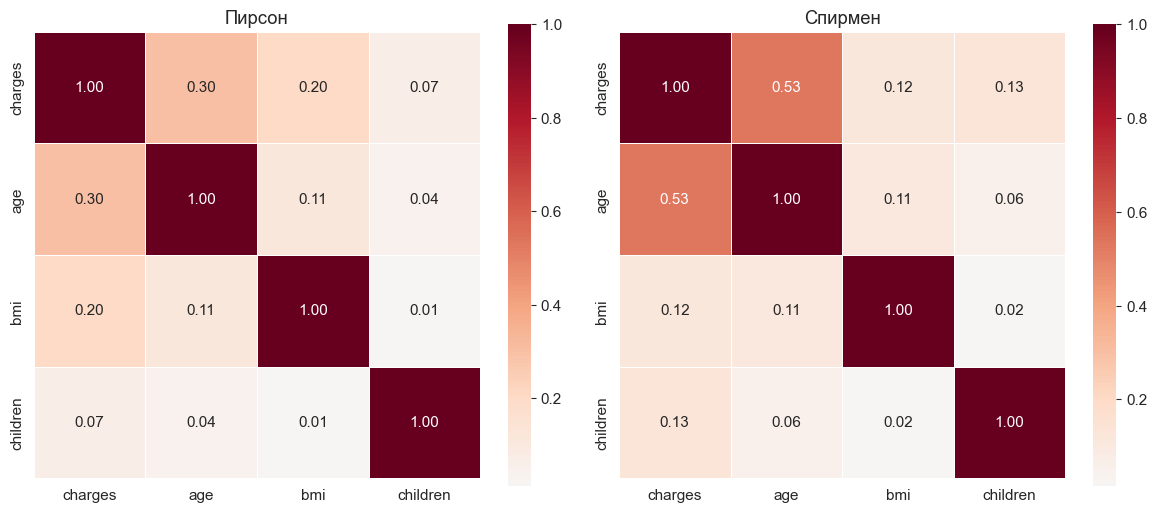

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Пирсон')

sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Спирмен')

plt.tight_layout()
plt.show()


In [37]:
from scipy.stats import t as student_t

def chaddock(abs_r):
    """Шкала Чеддока."""
    if abs_r >= 0.9:
        return 'весьма высокая'
    if abs_r >= 0.7:
        return 'высокая'
    if abs_r >= 0.5:
        return 'заметная'
    if abs_r >= 0.3:
        return 'умеренная'
    if abs_r >= 0.1:
        return 'слабая'
    return 'отсутствует'

n = len(df)
t_crit = student_t.ppf(1 - 0.05 / 2, n - 2)

print(f'Выборки не нормальны → сила и значимость по Спирмену. t_крит(α=0.05, df={n - 2}) = {t_crit:.3f}')
print(f'{"Пара":<22} {"Pearson r":>10} {"Spearman ρ":>12} {"t_r":>8} {"p":>12} {"Сила":>16}')
print('-' * 86)

for col in corr_vars:
    if col == 'charges':
        continue
    r_p, _ = pearsonr(df['charges'], df[col])
    r_s, p_s = spearmanr(df['charges'], df[col])
    t_r = abs(r_s) * np.sqrt((n - 2) / (1 - r_s ** 2))
    sig = 'значим' if t_r > t_crit else 'не значим'
    print(f'charges–{col:<14} {r_p:10.3f} {r_s:12.3f} {t_r:8.2f} {fmt_p(p_s):>12} {chaddock(abs(r_s)):>16} ({sig})')

print('\nСильные и слабые пары среди количественных признаков (Спирмен):')
for i, a in enumerate(corr_vars):
    for b in corr_vars[i + 1:]:
        r_s, _ = spearmanr(df[a], df[b])
        strength = chaddock(abs(r_s))
        if strength in ('высокая', 'весьма высокая', 'слабая', 'отсутствует'):
            print(f'  {a}–{b}: ρ = {r_s:.3f}, {strength}')


Выборки не нормальны → сила и значимость по Спирмену. t_крит(α=0.05, df=1336) = 1.962
Пара                    Pearson r   Spearman ρ      t_r            p             Сила
--------------------------------------------------------------------------------------
charges–age                 0.299        0.534    23.11   1.1307e-99         заметная (значим)
charges–bmi                 0.198        0.119     4.40   1.1926e-05           слабая (значим)
charges–children            0.068        0.133     4.92   9.8468e-07           слабая (значим)

Сильные и слабые пары среди количественных признаков (Спирмен):
  charges–bmi: ρ = 0.119, слабая
  charges–children: ρ = 0.133, слабая
  age–bmi: ρ = 0.108, слабая
  age–children: ρ = 0.057, отсутствует
  bmi–children: ρ = 0.016, отсутствует


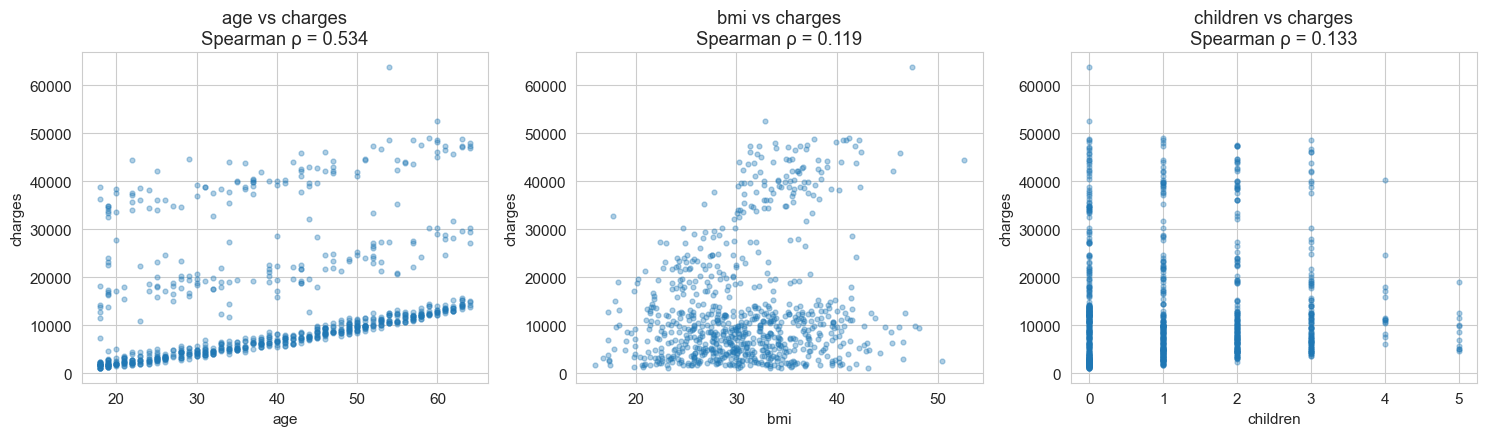

Интерпретация: с расходами заметно связан возраст; ИМТ и число детей — слабая, но значимая связь.
По таблицам сопряжённости главный фактор — курение: у курящих нет низких и средних расходов.
Пол независим от уровня расходов (p = 0.37). Регион связан слабее (p = 0.021), число детей — значимо.
Связь корреляционная, не причинная.


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['age', 'bmi', 'children']):
    sample = df.sample(min(800, len(df)), random_state=42)
    ax.scatter(sample[col], sample['charges'], alpha=0.35, s=12)
    r_s, _ = spearmanr(df[col], df['charges'])
    ax.set_xlabel(col)
    ax.set_ylabel('charges')
    ax.set_title(f'{col} vs charges\nSpearman ρ = {r_s:.3f}')
plt.tight_layout()
plt.show()

print('Интерпретация: с расходами заметно связан возраст; ИМТ и число детей — слабая, но значимая связь.')
print('По таблицам сопряжённости главный фактор — курение: у курящих нет низких и средних расходов.')
print('Пол независим от уровня расходов (p = 0.37). Регион связан слабее (p = 0.021), число детей — значимо.')
print('Связь корреляционная, не причинная.')


Таблица (ложная корреляция):


,Year,Cheese_lb,Bedsheet_deaths
0,2000,29.8,327
1,2001,30.1,456
2,2002,30.5,509
3,2003,30.6,497
4,2004,31.3,596
5,2005,31.7,573
6,2006,32.6,661
7,2007,33.1,741
8,2008,32.7,809
9,2009,32.8,717


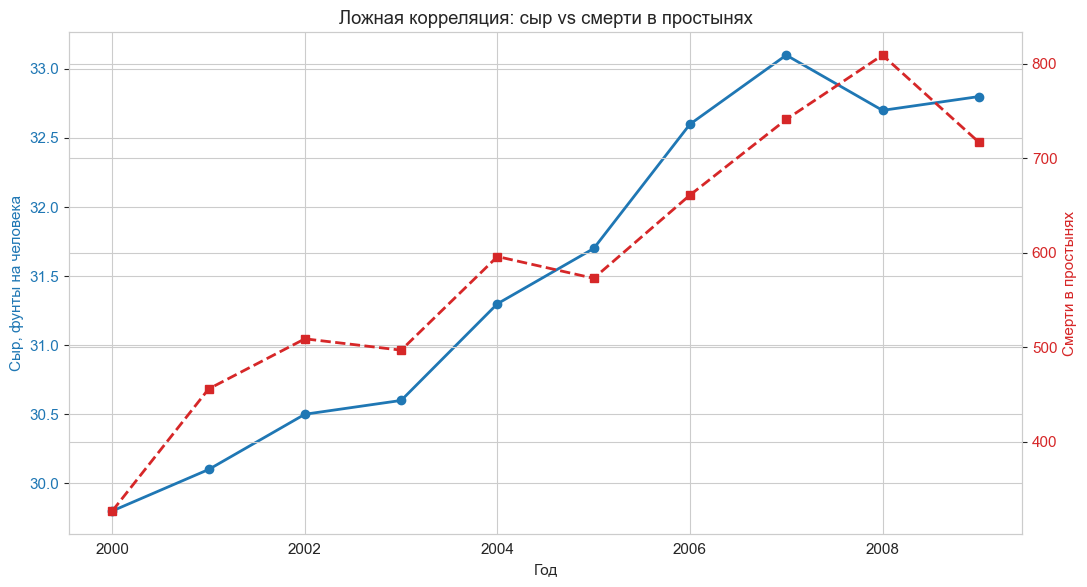

Исходная корреляция: r = 0.947, p = 3.2155e-05


In [39]:
# 9.1 Таблица и диаграмма с двумя осями.
# tylervigen.com: потребление сыра и смерти от запутывания в простынях, 2000–2009.
# Тот же пример, что на слайде «Ложная корреляция» (исходная связь около 95%).
years = np.arange(2000, 2010)
cheese = np.array([29.8, 30.1, 30.5, 30.6, 31.3, 31.7, 32.6, 33.1, 32.7, 32.8])
bedsheet = np.array([327, 456, 509, 497, 596, 573, 661, 741, 809, 717])

spurious = pd.DataFrame({
    'Year': years,
    'Cheese_lb': cheese,
    'Bedsheet_deaths': bedsheet,
})
print('Таблица (ложная корреляция):')
display(spurious)

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.set_xlabel('Год')
ax1.set_ylabel('Сыр, фунты на человека', color='tab:blue')
ax1.plot(spurious['Year'], spurious['Cheese_lb'], 'o-', color='tab:blue', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Смерти в простынях', color='tab:red')
ax2.plot(spurious['Year'], spurious['Bedsheet_deaths'], 's--', color='tab:red', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Ложная корреляция: сыр vs смерти в простынях')
fig.tight_layout()
plt.show()

r_spur, p_spur = pearsonr(spurious['Cheese_lb'], spurious['Bedsheet_deaths'])
print(f'Исходная корреляция: r = {r_spur:.3f}, p = {fmt_p(p_spur)}')


Выбор степени по скорректированному R²:
Cheese: d=1: R²=0.927, R²adj=0.918, d=2: R²=0.936, R²adj=0.918, d=3: R²=0.976, R²adj=0.964
Bedsheet: d=1: R²=0.902, R²adj=0.890, d=2: R²=0.916, R²adj=0.892, d=3: R²=0.918, R²adj=0.876


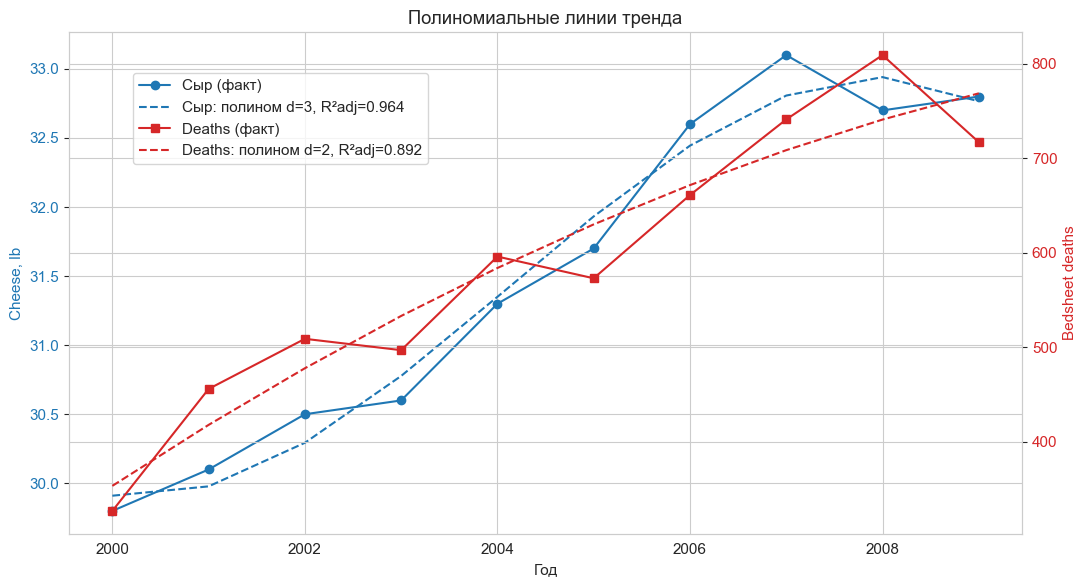

Cheese (d=3): y = − 0.0132·t^3 + 0.1637·t^2 − 0.0828·t + 29.9102
Bedsheet (d=2): y = − 2.2955·t^2 + 66.7803·t + 353.5091


In [40]:
# 9.2 Полиномиальные линии тренда; степень 1–3 выбирается по скорректированному R².
t = np.arange(len(years))

def select_poly_trend(x, y, max_degree=3):
    rows = []
    n = len(y)
    for degree in range(1, max_degree + 1):
        coef = np.polyfit(x, y, degree)
        fitted = np.polyval(coef, x)
        r2 = 1 - np.sum((y - fitted) ** 2) / np.sum((y - np.mean(y)) ** 2)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - degree - 1)
        rows.append((degree, coef, fitted, r2, adj_r2))
    return max(rows, key=lambda row: row[4]), rows

def poly_equation(coef):
    degree = len(coef) - 1
    parts = []
    for i, value in enumerate(coef):
        power = degree - i
        sign = '+' if value >= 0 and parts else ('−' if value < 0 else '')
        term = f'{abs(value):.4f}' if power == 0 else (
            f'{abs(value):.4f}·t' if power == 1 else f'{abs(value):.4f}·t^{power}'
        )
        parts.append(f'{sign} {term}'.strip())
    return ' '.join(parts)

(degree_c, coef_c, trend_c, r2_c, adj_c), candidates_c = select_poly_trend(t, cheese)
(degree_d, coef_d, trend_d, r2_d, adj_d), candidates_d = select_poly_trend(t, bedsheet)

print('Выбор степени по скорректированному R²:')
for name, rows in [('Cheese', candidates_c), ('Bedsheet', candidates_d)]:
    print(name + ': ' + ', '.join(
        f'd={degree}: R²={r2:.3f}, R²adj={adj:.3f}'
        for degree, _, _, r2, adj in rows
    ))

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(years, cheese, 'o-', color='tab:blue', label='Сыр (факт)')
ax1.plot(years, trend_c, '--', color='tab:blue',
         label=f'Сыр: полином d={degree_c}, R²adj={adj_c:.3f}')
ax1.set_ylabel('Cheese, lb', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(years, bedsheet, 's-', color='tab:red', label='Deaths (факт)')
ax2.plot(years, trend_d, '--', color='tab:red',
         label=f'Deaths: полином d={degree_d}, R²adj={adj_d:.3f}')
ax2.set_ylabel('Bedsheet deaths', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xlabel('Год')
ax1.set_title('Полиномиальные линии тренда')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

print(f'Cheese (d={degree_c}): y = {poly_equation(coef_c)}')
print(f'Bedsheet (d={degree_d}): y = {poly_equation(coef_d)}')


In [41]:
# 9.3–9.5 Предсказания, остатки, стандартизированные остатки
spurious['Cheese_pred'] = trend_c
spurious['Death_pred'] = trend_d
spurious['Cheese_resid'] = spurious['Cheese_lb'] - spurious['Cheese_pred']
spurious['Death_resid'] = spurious['Bedsheet_deaths'] - spurious['Death_pred']
spurious['Cheese_std_resid'] = (
    (spurious['Cheese_resid'] - spurious['Cheese_resid'].mean()) / spurious['Cheese_resid'].std()
)
spurious['Death_std_resid'] = (
    (spurious['Death_resid'] - spurious['Death_resid'].mean()) / spurious['Death_resid'].std()
)

print('Таблица с остатками:')
display(spurious.round(3))


Таблица с остатками:


,Year,Cheese_lb,Bedsheet_deaths,Cheese_pred,Death_pred,Cheese_resid,Death_resid,Cheese_std_resid,Death_std_resid
0,2000,29.8,327,29.910,353.509,-0.110,-26.509,-0.578,-0.623
1,2001,30.1,456,29.978,417.994,0.122,38.006,0.641,0.893
2,2002,30.5,509,30.293,477.888,0.207,31.112,1.085,0.731
3,2003,30.6,497,30.777,533.191,-0.177,-36.191,-0.930,-0.850
4,2004,31.3,596,31.350,583.903,-0.050,12.097,-0.263,0.284
5,2005,31.7,573,31.932,630.024,-0.232,-57.024,-1.219,-1.340
6,2006,32.6,661,32.445,671.555,0.155,-10.555,0.816,-0.248
7,2007,33.1,741,32.807,708.494,0.293,32.506,1.536,0.764
8,2008,32.7,809,32.941,740.842,-0.241,68.158,-1.265,1.602
9,2009,32.8,717,32.766,768.600,0.034,-51.600,0.178,-1.213


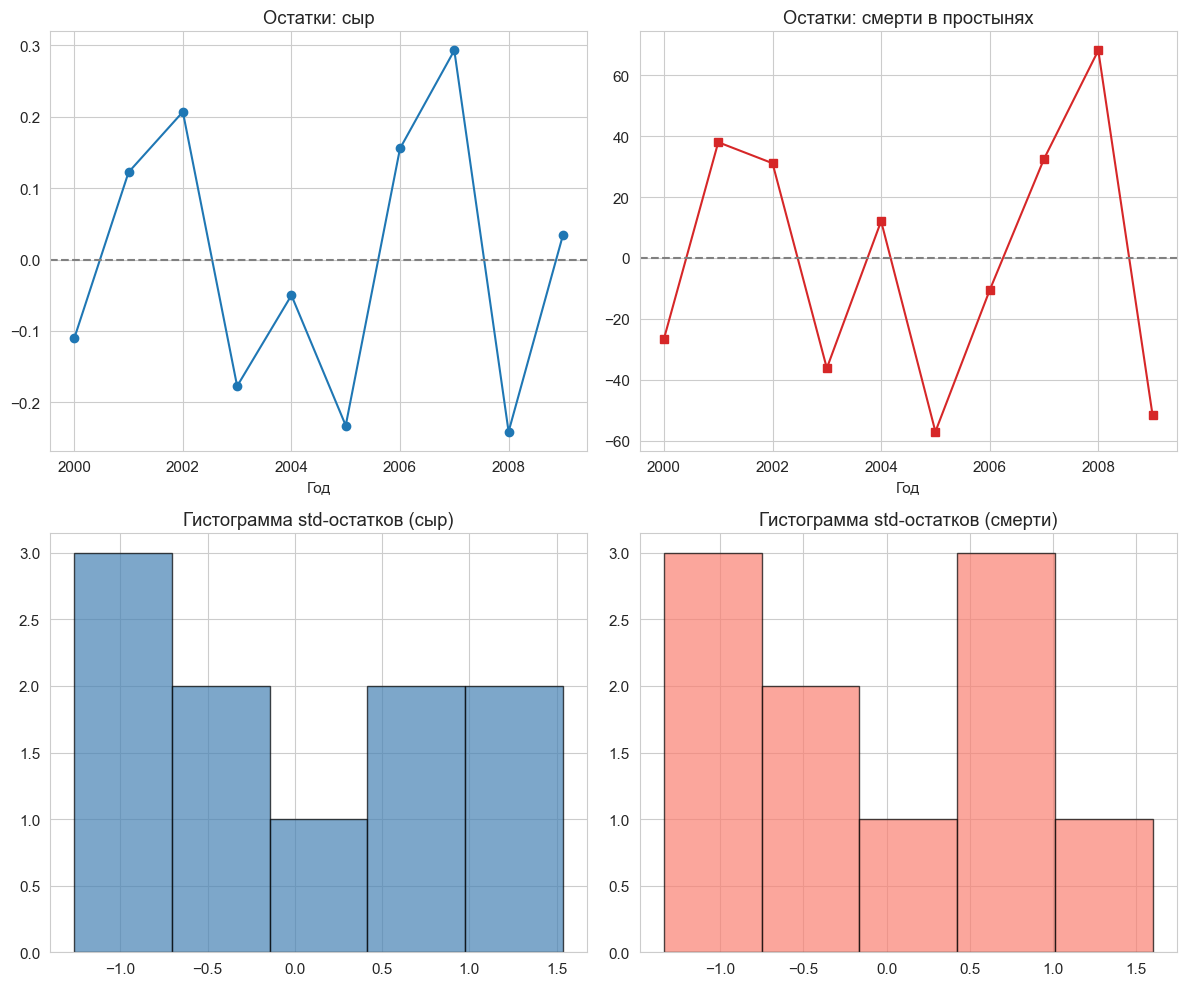

In [42]:
# 9.6 График остатков и гистограммы стандартизированных остатков
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].plot(years, spurious['Cheese_resid'], 'o-', color='tab:blue')
axes[0, 0].axhline(0, color='gray', linestyle='--')
axes[0, 0].set_title('Остатки: сыр')
axes[0, 0].set_xlabel('Год')

axes[0, 1].plot(years, spurious['Death_resid'], 's-', color='tab:red')
axes[0, 1].axhline(0, color='gray', linestyle='--')
axes[0, 1].set_title('Остатки: смерти в простынях')
axes[0, 1].set_xlabel('Год')

axes[1, 0].hist(spurious['Cheese_std_resid'], bins=5, edgecolor='black',
                color='steelblue', alpha=0.7)
axes[1, 0].set_title('Гистограмма std-остатков (сыр)')

axes[1, 1].hist(spurious['Death_std_resid'], bins=5, edgecolor='black',
                color='salmon', alpha=0.7)
axes[1, 1].set_title('Гистограмма std-остатков (смерти)')

plt.tight_layout()
plt.show()


In [43]:
# 9.7–9.9 Корреляция остатков, значимость, вывод
r_resid, p_resid = pearsonr(spurious['Cheese_resid'], spurious['Death_resid'])
n_s = len(spurious)
t_resid = abs(r_resid) * np.sqrt((n_s - 2) / (1 - r_resid ** 2))
t_crit_s = student_t.ppf(1 - 0.05 / 2, n_s - 2)

print(f'Корреляция остатков: r = {r_resid:.4f}, t_r = {t_resid:.3f}, t_крит = {t_crit_s:.3f}, p = {fmt_p(p_resid)}')
print(f'Исходная корреляция рядов: r = {r_spur:.3f}, p = {fmt_p(p_spur)}')

if p_resid > 0.05:
    print('Корреляция остатков не значима: после удаления общего тренда связь исчезла.')
else:
    print('Корреляция остатков всё ещё значима.')

print('Причина ложной корреляции — общая тенденция роста обоих рядов во времени,')
print('а не причинная связь между сыром и смертями. Это совпадение двух трендов.')


Корреляция остатков: r = 0.3118, t_r = 0.928, t_крит = 2.306, p = 3.8039e-01
Исходная корреляция рядов: r = 0.947, p = 3.2155e-05
Корреляция остатков не значима: после удаления общего тренда связь исчезла.
Причина ложной корреляции — общая тенденция роста обоих рядов во времени,
а не причинная связь между сыром и смертями. Это совпадение двух трендов.


## ЛР 1.2. Регрессионный анализ

Пункты 1–3 выполнены выше на `insurance.csv`. Дальше — пункты 4–12.

Зависимая переменная `charges` непрерывная и положительная, не счётчик. По типу переменной выбирается линейная регрессия. Для неё считаем AIC и BIC при нормальных ошибках. Пуассоновскую модель строим отдельно, как требует пункт 11. Дополнительно — гамма-GLM и квантильная регрессия: этих двух видов в методичках ЛР 1.2 нет. Базовые уровни фиктивных переменных: женщина, не курит, регион northeast.


### Вспомогательные функции

Короткие имена коэффициентов, запись уравнения, AIC/BIC нормальной модели, качество МНК, эластичность и отчёт по остаткам.


In [21]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy import stats


def short_term(name):
    repl = {
        "C(Seasons, Treatment(reference='Winter'))[T.": "Season:",
        "C(Holiday, Treatment(reference='No Holiday'))[T.": "Holiday:",
        "C(Functioning, Treatment(reference='Yes'))[T.": "Functioning:",
        "C(sex, Treatment(reference='female'))[T.": "sex:",
        "C(smoker, Treatment(reference='no'))[T.": "smoker:",
        "C(region, Treatment(reference='northeast'))[T.": "region:",
    }
    for old, new in repl.items():
        name = name.replace(old, new)
    return name.replace("]", "")


def write_equation(model, left):
    chunks = []
    for name, coef in model.params.items():
        label = "1" if name == "Intercept" else short_term(name)
        if not chunks:
            chunks.append(f"{coef:.4f}" if name == "Intercept" else f"{coef:.4f}·{label}")
        else:
            sign = "+" if coef >= 0 else "−"
            chunks.append(f" {sign} {abs(coef):.4f}·{label}")
    print(left + " = " + "".join(chunks))


def gaussian_aic_bic(resid, n_params):
    """AIC/BIC при нормальных ошибках: ε ~ N(0, σ²), σ² = SSE/n (ММП)."""
    resid = np.asarray(resid)
    n = len(resid)
    sse = np.sum(resid ** 2)
    sigma2 = sse / n
    ll = -n / 2 * np.log(2 * np.pi) - n / 2 * np.log(sigma2) - sse / (2 * sigma2)
    aic = -2 * ll + 2 * n_params
    bic = -2 * ll + n_params * np.log(n)
    return ll, aic, bic, sigma2


def ols_quality(model, y_name):
    n = int(model.nobs)
    k = int(model.df_model)
    r2 = model.rsquared
    r2_adj = 1 - (1 - r2) * n / (n - k - 1)
    f_crit = stats.f.ppf(0.95, model.df_model, model.df_resid)
    t_crit = stats.t.ppf(0.975, model.df_resid)
    df_resid = n - k - 1
    p_params = k + 1
    ll, aic, bic, sigma2 = gaussian_aic_bic(model.resid, p_params)
    print(f"R² = {r2:.4f}   R²_скорр = {r2_adj:.4f}   n = {n}, k = {k}")
    print(f"Степени свободы остатков: df = n − k − 1 = {n} − {k} − 1 = {df_resid}")
    print("Нормальная модель ошибок: ε ~ N(0, σ²), σ²_MMП = SSE/n")
    print(f"ln L = −n/2·ln(2π) − n/2·ln(σ²) − SSE/(2σ²) = {ll:.3f}")
    print(f"AIC = −2 ln L + 2p = {aic:.3f}   BIC = −2 ln L + p·ln n = {bic:.3f}   p = {p_params}")
    print(f"statsmodels AIC = {model.aic:.3f}, BIC = {model.bic:.3f} (совпадают с ручным расчётом)")
    print(f"F = {model.fvalue:.3f}, F_крит(0.05; {k}, {int(model.df_resid)}) = {f_crit:.3f}, p = {fmt_p(model.f_pvalue)}")
    if model.fvalue > f_crit:
        print("Уравнение в целом значимо: H0 (все β = 0) отвергается.")
    else:
        print("Уравнение в целом не значимо.")
    if r2 >= 0.75:
        print("По порогу со слайда диагностики (R² ≥ 0.75) модель приемлема.")
    else:
        print("По порогу со слайда диагностики (R² ≥ 0.75) модель слабая: доля объяснённой вариации меньше 75%.")
    print(f"\nЗначимость коэффициентов, t_крит = {t_crit:.3f}, df = {int(model.df_resid)}")
    print(f"{'Коэффициент':<28} {'оценка':>12} {'t':>10} {'p':>12} {'вывод':>12}")
    for name, coef in model.params.items():
        t = model.tvalues[name]
        p = model.pvalues[name]
        verdict = "значим" if abs(t) > t_crit else "не значим"
        print(f"{short_term(name):<28} {coef:12.4f} {t:10.2f} {fmt_p(p):>12} {verdict:>12}")
    write_equation(model, y_name)


def influence_table(model, frame, y_name, factors):
    y = frame[y_name]
    sy = y.std(ddof=1)
    print("Средняя эластичность, бета- и дельта-коэффициенты (количественные факторы)")
    print(f"{'Фактор':<12} {'Э':>8} {'β':>8} {'Δ':>8}")
    deltas = []
    for col in factors:
        b = model.params[col]
        elast = b * frame[col].mean() / y.mean()
        beta = b * frame[col].std(ddof=1) / sy
        delta = frame[col].corr(y) * beta / model.rsquared
        deltas.append(delta)
        print(f"{col:<12} {elast:8.3f} {beta:8.3f} {delta:8.3f}")
    print(f"Сумма дельта-коэффициентов по этим факторам: {sum(deltas):.3f}")


def partial_corr(y, x1, x2):
    r_y1 = np.corrcoef(y, x1)[0, 1]
    r_y2 = np.corrcoef(y, x2)[0, 1]
    r_12 = np.corrcoef(x1, x2)[0, 1]
    num = r_y1 - r_y2 * r_12
    den = np.sqrt((1 - r_y2 ** 2) * (1 - r_12 ** 2))
    return num / den, r_y1


def residual_report(y, fitted, title, ordered):
    resid = np.asarray(y) - np.asarray(fitted)
    std_resid = (resid - resid.mean()) / resid.std(ddof=1)
    print(f"=== Остатки: {title} ===")
    mae = np.mean(np.abs(resid))
    rmse = np.sqrt(np.mean(resid ** 2))
    print(f"Среднее остатков = {resid.mean():.3e}")
    print(f"MAE = {mae:.3f}, RMSE = {rmse:.3f}")
    print(
        "Близкая к нулю сумма сырых остатков — свойство оценивания модели с константой "
        "(точно для МНК и из score-уравнения для Пуассона); качество показывают MAE/RMSE и структура остатков."
    )
    q1, q2 = np.quantile(fitted, [1 / 3, 2 / 3])
    v_low = resid[fitted <= q1].var(ddof=1)
    v_mid = resid[(fitted > q1) & (fitted <= q2)].var(ddof=1)
    v_high = resid[fitted > q2].var(ddof=1)
    print(f"Дисперсия остатков по третям прогноза: {v_low:.1f} | {v_mid:.1f} | {v_high:.1f}")
    ratio = max(v_low, v_mid, v_high) / min(v_low, v_mid, v_high)
    if ratio < 2:
        print("Дисперсия остатков примерно постоянна.")
    else:
        print(f"Дисперсия остатков не постоянна (разброс третей в {ratio:.1f} раза): гетероскедастичность.")
    dw = durbin_watson(resid)
    print(f"Дарбин–Уотсон DW = {dw:.3f} (около 2 — остатки не коррелируют).")
    if not ordered:
        print("Наблюдения не являются временным рядом, DW здесь вспомогательный.")
    k = int(np.ceil(1 + 3.322 * np.log10(len(resid))))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].scatter(np.arange(len(resid)), resid, s=8, alpha=0.25, color="navy")
    axes[0].axhline(0, color="gray", linestyle="--")
    axes[0].set_title(f"Остатки: {title}")
    axes[0].set_xlabel("Номер наблюдения")
    axes[0].set_ylabel("Остаток")
    axes[1].hist(std_resid, bins=k, edgecolor="black", color="steelblue", alpha=0.8)
    axes[1].set_title(f"Стандартизированные остатки, k={k}")
    axes[1].set_xlabel("std-остаток")
    plt.tight_layout()
    plt.show()
    return resid


y_name = "charges"
numeric_factors = ["age", "bmi", "children"]
lin_formula = (
    "charges ~ age + bmi + children"
    " + C(sex, Treatment(reference='female'))"
    " + C(smoker, Treatment(reference='no'))"
    " + C(region, Treatment(reference='northeast'))"
)


### 4–5, 8–10. Линейная модель с фиктивными переменными (МНК)

Нормальные ошибки $\varepsilon \sim N(0,\sigma^2)$. AIC и BIC считаются по ММП: $\sigma^2 = \mathrm{SSE}/n$.


In [23]:
lin = smf.ols(lin_formula, data=df).fit()
print("Линейная регрессия, метод наименьших квадратов")
ols_quality(lin, "charges")


Линейная регрессия, метод наименьших квадратов
R² = 0.7509   R²_скорр = 0.7492   n = 1338, k = 8
Степени свободы остатков: df = n − k − 1 = 1338 − 8 − 1 = 1329
Нормальная модель ошибок: ε ~ N(0, σ²), σ²_MMП = SSE/n
ln L = −n/2·ln(2π) − n/2·ln(σ²) − SSE/(2σ²) = -13547.753
AIC = −2 ln L + 2p = 27113.506   BIC = −2 ln L + p·ln n = 27160.296   p = 9
statsmodels AIC = 27113.506, BIC = 27160.296 (совпадают с ручным расчётом)
F = 500.811, F_крит(0.05; 8, 1329) = 1.945, p = < 1e-300
Уравнение в целом значимо: H0 (все β = 0) отвергается.
По порогу со слайда диагностики (R² ≥ 0.75) модель приемлема.

Значимость коэффициентов, t_крит = 1.962, df = 1329
Коэффициент                        оценка          t            p        вывод
Intercept                     -11938.5386     -12.09   5.5790e-32       значим
sex:male                        -131.3144      -0.39   6.9335e-01    не значим
smoker:yes                     23848.5345      57.72     < 1e-300       значим
region:northwest                -3

### Эластичность, β- и Δ-коэффициенты

Количественные факторы: `age`, `bmi`, `children`.


In [25]:
influence_table(lin, df, "charges", numeric_factors)


Средняя эластичность, бета- и дельта-коэффициенты (количественные факторы)
Фактор              Э        β        Δ
age             0.759    0.298    0.119
bmi             0.784    0.171    0.045
children        0.039    0.047    0.004
Сумма дельта-коэффициентов по этим факторам: 0.168


### Частная корреляция `charges`–`age` при исключении `bmi`


In [27]:
r_part, r_pair = partial_corr(df["charges"], df["age"], df["bmi"])
print(f"Парная корреляция charges–age = {r_pair:.3f}")
print(f"Частная корреляция charges–age при исключении bmi = {r_part:.3f}")


Парная корреляция charges–age = 0.299
Частная корреляция charges–age при исключении bmi = 0.285


### 6–7. Остатки линейной модели


=== Остатки: линейная модель ===
Среднее остатков = -9.690e-12
MAE = 4170.887, RMSE = 6041.680
Близкая к нулю сумма сырых остатков — свойство оценивания модели с константой (точно для МНК и из score-уравнения для Пуассона); качество показывают MAE/RMSE и структура остатков.
Дисперсия остатков по третям прогноза: 23675383.0 | 23550999.8 | 61583206.0
Дисперсия остатков не постоянна (разброс третей в 2.6 раза): гетероскедастичность.
Дарбин–Уотсон DW = 2.088 (около 2 — остатки не коррелируют).
Наблюдения не являются временным рядом, DW здесь вспомогательный.
Нулевое среднее не означает идеальную модель: это алгебраическое свойство МНК с константой. Смотрите MAE, RMSE, дисперсию и график.


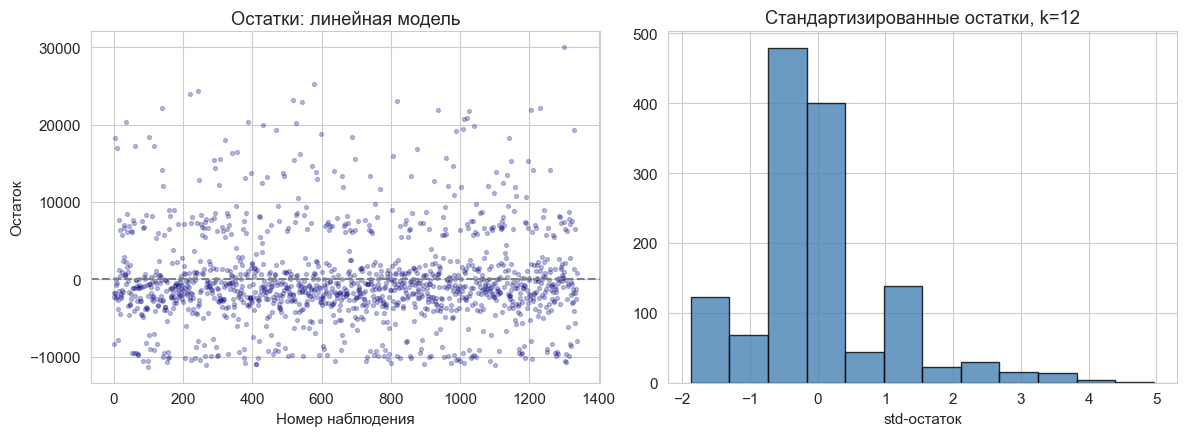

In [29]:
residual_report(df[y_name], lin.fittedvalues, "линейная модель", ordered=False)
print("Нулевое среднее не означает идеальную модель: это алгебраическое свойство МНК с константой. Смотрите MAE, RMSE, дисперсию и график.")


### 11. Пуассоновская регрессия

`charges` не счётчик: модель строится по пункту задания, затем проверяется сверхдисперсия.


In [31]:
poi = smf.poisson(lin_formula, data=df).fit(disp=False, method='newton', maxiter=1000)
print(f"Сходимость оптимизации: {poi.mle_retvals['converged']}")
mu = poi.predict()
phi = np.sum((df[y_name] - mu) ** 2 / mu) / poi.df_resid
pseudo_r2 = 1 - poi.llf / poi.llnull
chi_crit = stats.chi2.ppf(0.95, poi.df_model)
z_crit = stats.norm.ppf(0.975)

print("Пуассоновская регрессия: ln(λ) = Xβ, λ = exp(Xβ), оценки ММП.")
print("charges непрерывны, условие целочисленного отклика и равенства среднего и дисперсии не выполнено.")
write_equation(poi, "ln(λ)")
print(f"\nПсевдо-R² = {pseudo_r2:.4f}")
print(f"LR = {poi.llr:.1f}, χ²_крит(0.05, df={int(poi.df_model)}) = {chi_crit:.3f}, p = {fmt_p(poi.llr_pvalue)}")
print("Модель значима относительно константы." if poi.llr > chi_crit else "Модель не значима относительно константы.")
print(f"\nКоэффициенты, z-тест Вальда, z_крит = {z_crit:.3f}")
print(f"{'Коэффициент':<22} {'оценка':>12} {'z':>10} {'p':>12}")
for name, coef in poi.params.items():
    print(f"{short_term(name):<22} {coef:12.4f} {poi.tvalues[name]:10.2f} {fmt_p(poi.pvalues[name]):>12}")
print(f"\nφ = D / M ≈ {phi:.1f}. Для Пуассона нужно φ ≈ 1.")
print("Сверхдисперсия очень сильная: z-тесты завышают значимость. Для расходов линейная модель уместнее.")


Сходимость оптимизации: True
Пуассоновская регрессия: ln(λ) = Xβ, λ = exp(Xβ), оценки ММП.
charges непрерывны, условие целочисленного отклика и равенства среднего и дисперсии не выполнено.
ln(λ) = 7.4266 − 0.0225·sex:male + 1.3573·smoker:yes − 0.0395·region:northwest − 0.0945·region:southeast − 0.0689·region:southwest + 0.0199·age + 0.0257·bmi + 0.0416·children

Псевдо-R² = 0.7409
LR = 9327362.8, χ²_крит(0.05, df=8) = 15.507, p = < 1e-300
Модель значима относительно константы.

Коэффициенты, z-тест Вальда, z_крит = 1.960
Коэффициент                  оценка          z            p
Intercept                    7.4266    4986.43     < 1e-300
sex:male                    -0.0225     -46.89     < 1e-300
smoker:yes                   1.3573    2827.36     < 1e-300
region:northwest            -0.0395     -57.00     < 1e-300
region:southeast            -0.0945    -141.44     < 1e-300
region:southwest            -0.0689     -98.87     < 1e-300
age                          0.0199    1148.39     < 

### Остатки пуассоновской модели


=== Остатки: пуассоновская модель ===
Среднее остатков = 1.599e-12
MAE = 3946.331, RMSE = 5958.891
Близкая к нулю сумма сырых остатков — свойство оценивания модели с константой (точно для МНК и из score-уравнения для Пуассона); качество показывают MAE/RMSE и структура остатков.
Дисперсия остатков по третям прогноза: 22458231.5 | 23711510.1 | 59303965.0
Дисперсия остатков не постоянна (разброс третей в 2.6 раза): гетероскедастичность.
Дарбин–Уотсон DW = 2.125 (около 2 — остатки не коррелируют).
Наблюдения не являются временным рядом, DW здесь вспомогательный.


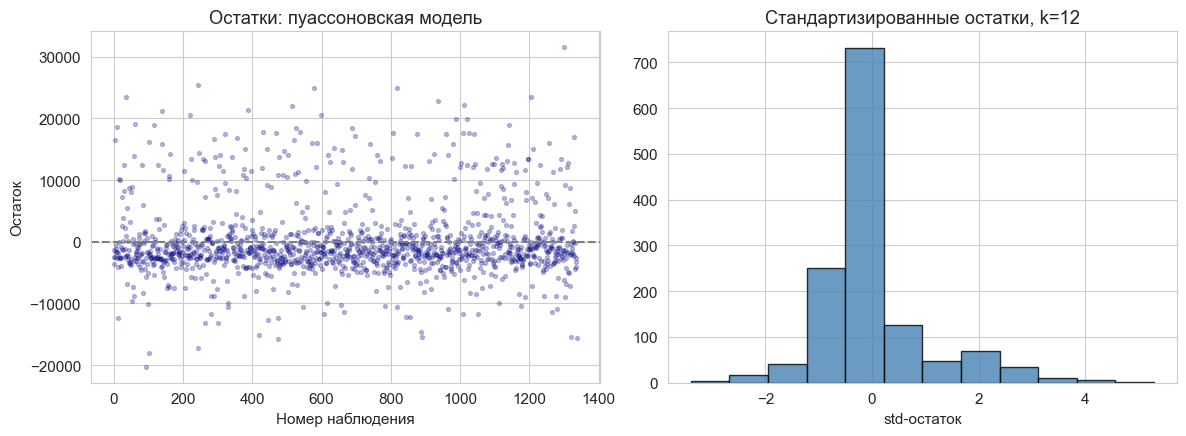

In [33]:
residual_report(df[y_name], mu, "пуассоновская модель", ordered=False)


### 12. Нелинейная модель: age² и bmi²

Фиктивные переменные те же. Модель линейна по коэффициентам, нелинейна по факторам.


In [35]:
nl_formula = (
    "charges ~ age + I(age**2) + bmi + I(bmi**2) + children"
    " + C(sex, Treatment(reference='female'))"
    " + C(smoker, Treatment(reference='no'))"
    " + C(region, Treatment(reference='northeast'))"
)
nl = smf.ols(nl_formula, data=df).fit()
print("Нелинейная по факторам, линейная по коэффициентам")
ols_quality(nl, "charges")


Нелинейная по факторам, линейная по коэффициентам
R² = 0.7547   R²_скорр = 0.7526   n = 1338, k = 10
Степени свободы остатков: df = n − k − 1 = 1338 − 10 − 1 = 1327
Нормальная модель ошибок: ε ~ N(0, σ²), σ²_MMП = SSE/n
ln L = −n/2·ln(2π) − n/2·ln(σ²) − SSE/(2σ²) = -13537.603
AIC = −2 ln L + 2p = 27097.206   BIC = −2 ln L + p·ln n = 27154.395   p = 11
statsmodels AIC = 27097.206, BIC = 27154.395 (совпадают с ручным расчётом)
F = 408.190, F_крит(0.05; 10, 1327) = 1.838, p = < 1e-300
Уравнение в целом значимо: H0 (все β = 0) отвергается.
По порогу со слайда диагностики (R² ≥ 0.75) модель приемлема.

Значимость коэффициентов, t_крит = 1.962, df = 1327
Коэффициент                        оценка          t            p        вывод
Intercept                     -13545.8254      -3.87   1.1461e-04       значим
sex:male                        -139.8907      -0.42   6.7234e-01    не значим
smoker:yes                     23874.9061      58.17     < 1e-300       значим
region:northwest           

### Остатки нелинейной модели


=== Остатки: нелинейная модель ===
Среднее остатков = 6.984e-10
MAE = 4204.866, RMSE = 5996.022
Близкая к нулю сумма сырых остатков — свойство оценивания модели с константой (точно для МНК и из score-уравнения для Пуассона); качество показывают MAE/RMSE и структура остатков.
Дисперсия остатков по третям прогноза: 22999363.1 | 23202095.2 | 61022703.9
Дисперсия остатков не постоянна (разброс третей в 2.7 раза): гетероскедастичность.
Дарбин–Уотсон DW = 2.092 (около 2 — остатки не коррелируют).
Наблюдения не являются временным рядом, DW здесь вспомогательный.


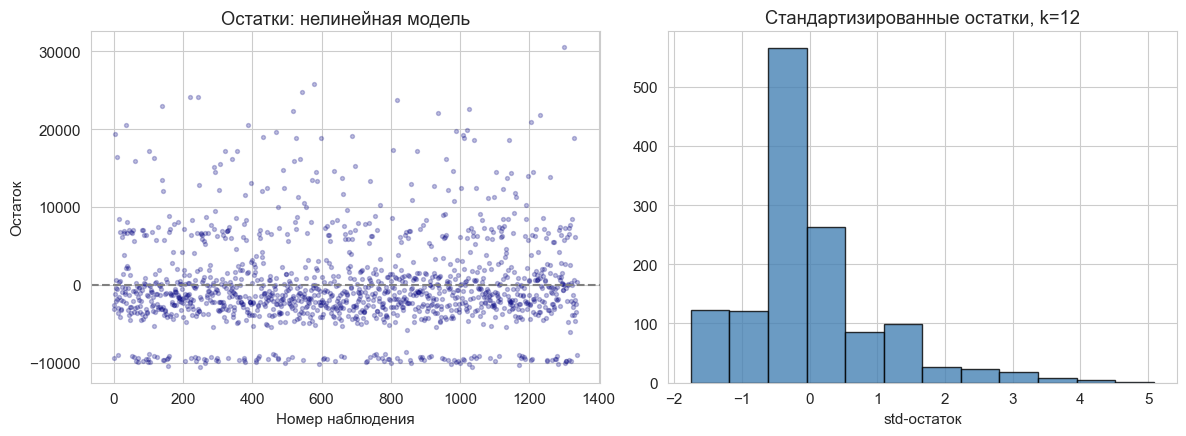

In [37]:
residual_report(df[y_name], nl.fittedvalues, "нелинейная модель", ordered=False)


### Гамма-GLM с логарифмической связью

Этого вида нет в методичках ЛР 1.2. Для положительных скошенных `charges`: $\mathrm{Var}(Y)=\varphi\mu^2$, $\ln\mu = X\beta$.


In [39]:
gamma = smf.glm(
    lin_formula, data=df,
    family=sm.families.Gamma(sm.families.links.Log()),
).fit()
mu_g = gamma.fittedvalues
print(f"Сходимость: {gamma.converged}")
print("Гамма-GLM, ln μ = Xβ")
write_equation(gamma, "ln μ")
print(f"\nln L = {gamma.llf:.3f}")
print(f"AIC = {gamma.aic:.3f}   BIC = {gamma.bic_llf:.3f}")
print(f"φ (дисперсионный параметр) = {gamma.scale:.3f}")
print("AIC/BIC сравнимы с линейной нормальной моделью: меньше — лучше.")
z_crit = stats.norm.ppf(0.975)
print(f"\nКоэффициенты, z-тест Вальда, z_крит = {z_crit:.3f}")
print(f"{'Коэффициент':<22} {'оценка':>12} {'z':>10} {'p':>12}")
for name, coef in gamma.params.items():
    print(f"{short_term(name):<22} {coef:12.4f} {gamma.tvalues[name]:10.2f} {fmt_p(gamma.pvalues[name]):>12}")
smoker_key = "C(smoker, Treatment(reference='no'))[T.yes]"
print("exp(β_smoker) − 1: при прочих равных курение умножает средний расход примерно на",
      f"{np.exp(gamma.params[smoker_key]):.2f}.")


Сходимость: True
Гамма-GLM, ln μ = Xβ
ln μ = 7.3863 − 0.0571·sex:male + 1.5003·smoker:yes − 0.0579·region:northwest − 0.1416·region:southeast − 0.1455·region:southwest + 0.0286·age + 0.0141·bmi + 0.0842·children

ln L = -13307.419
AIC = 26632.838   BIC = 26679.628
φ (дисперсионный параметр) = 0.467
AIC/BIC сравнимы с линейной нормальной моделью: меньше — лучше.

Коэффициенты, z-тест Вальда, z_крит = 1.960
Коэффициент                  оценка          z            p
Intercept                    7.3863      66.33     < 1e-300
sex:male                    -0.0571      -1.52   1.2830e-01
smoker:yes                   1.5003      32.22  1.0769e-227
region:northwest            -0.0579      -1.08   2.8104e-01
region:southeast            -0.1416      -2.62   8.6682e-03
region:southwest            -0.1455      -2.70   6.9255e-03
age                          0.0286      21.35  3.7948e-101
bmi                          0.0141       4.38   1.1812e-05
children                     0.0842       5.42   6.

### Остатки гамма-GLM


=== Остатки: гамма-GLM ===
Среднее остатков = -6.277e+02
MAE = 4389.009, RMSE = 7770.693
Близкая к нулю сумма сырых остатков — свойство оценивания модели с константой (точно для МНК и из score-уравнения для Пуассона); качество показывают MAE/RMSE и структура остатков.
Дисперсия остатков по третям прогноза: 21955492.5 | 18945221.0 | 135505208.7
Дисперсия остатков не постоянна (разброс третей в 7.2 раза): гетероскедастичность.
Дарбин–Уотсон DW = 2.062 (около 2 — остатки не коррелируют).
Наблюдения не являются временным рядом, DW здесь вспомогательный.


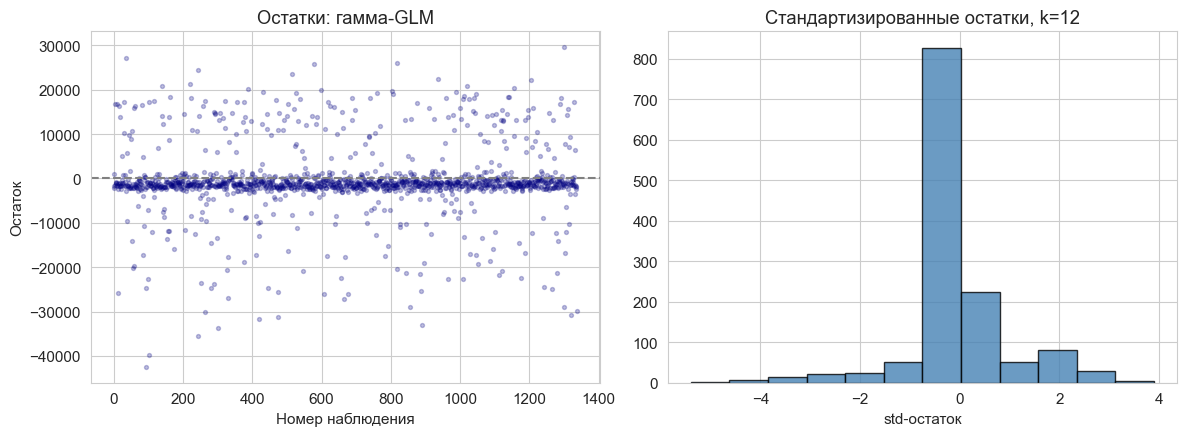

In [41]:
residual_report(df[y_name], mu_g, "гамма-GLM", ordered=False)


### Квантильная регрессия (τ = 0.5)

Этого вида нет в методичках. МНК оценивает условное среднее; квантиль 0.5 минимизирует сумму абсолютных остатков (условная медиана).


In [43]:
q50 = smf.quantreg(lin_formula, data=df).fit(q=0.5)
print("Квантильная регрессия, τ = 0.5 (условная медиана)")
write_equation(q50, "Q_{0.5}(charges | X)")
print(f"\nпсевдо-R² (Koenker) = {q50.prsquared:.4f}")
print("AIC/BIC для квантильной модели в гауссовском виде не считаем: правдоподобие не нормальное.")
print(f"\n{'Коэффициент':<22} {'оценка':>12} {'t':>10} {'p':>12}")
for name, coef in q50.params.items():
    print(f"{short_term(name):<22} {coef:12.4f} {q50.tvalues[name]:10.2f} {fmt_p(q50.pvalues[name]):>12}")


Квантильная регрессия, τ = 0.5 (условная медиана)
Q_{0.5}(charges | X) = -4404.6758 − 464.2943·sex:male + 31219.0313·smoker:yes − 251.0422·region:northwest − 670.7772·region:southeast − 668.9684·region:southwest + 263.2700·age + 42.5661·bmi + 401.3570·children

псевдо-R² (Koenker) = 0.5921
AIC/BIC для квантильной модели в гауссовском виде не считаем: правдоподобие не нормальное.

Коэффициент                  оценка          t            p
Intercept                -4404.6758     -22.78   2.8617e-97
sex:male                  -464.2943      -7.13   1.6956e-12
smoker:yes               31219.0313     386.10     < 1e-300
region:northwest          -251.0422      -2.69   7.1643e-03
region:southeast          -670.7772      -7.16   1.3308e-12
region:southwest          -668.9684      -7.15   1.4074e-12
age                        263.2700     113.06     < 1e-300
bmi                         42.5661       7.61   5.3635e-14
children                   401.3570      14.88   1.9023e-46


### Остатки квантильной модели и сравнение с τ = 0.9


=== Остатки: квантильная τ=0.5 ===
Среднее остатков = -1.442e+02
MAE = 3406.388, RMSE = 6961.461
Близкая к нулю сумма сырых остатков — свойство оценивания модели с константой (точно для МНК и из score-уравнения для Пуассона); качество показывают MAE/RMSE и структура остатков.
Дисперсия остатков по третям прогноза: 23055748.7 | 17313295.8 | 94273742.3
Дисперсия остатков не постоянна (разброс третей в 5.4 раза): гетероскедастичность.
Дарбин–Уотсон DW = 2.017 (около 2 — остатки не коррелируют).
Наблюдения не являются временным рядом, DW здесь вспомогательный.
Для сравнения: при τ = 0.9 оценивается верхний хвост расходов.
smoker при τ=0.5: 31219.0; при τ=0.9: 27193.2
Сдвиг от курения в верхнем хвосте больше, чем у медианы: распределение расходов неоднородно.


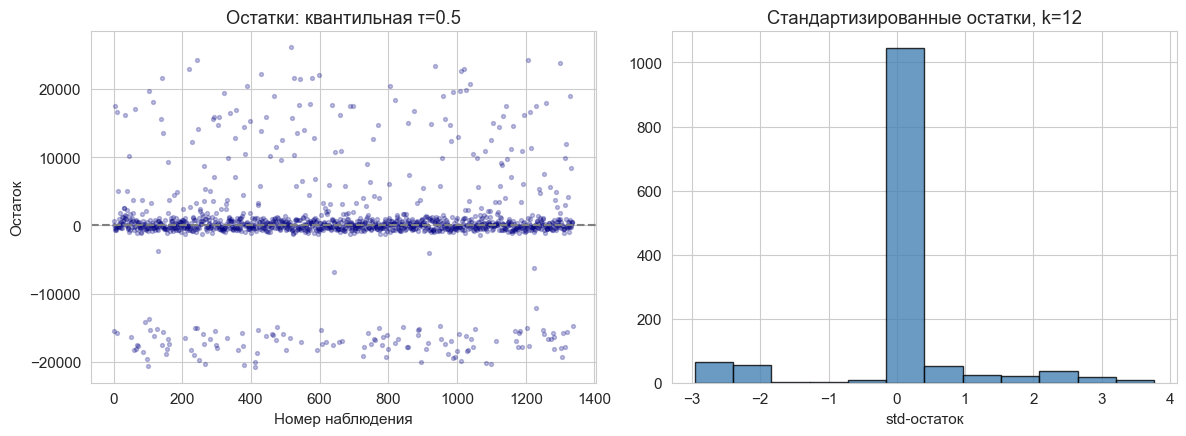

In [45]:
residual_report(df[y_name], q50.fittedvalues, "квантильная τ=0.5", ordered=False)
print("Для сравнения: при τ = 0.9 оценивается верхний хвост расходов.")
q90 = smf.quantreg(lin_formula, data=df).fit(q=0.9)
smoker_key = "C(smoker, Treatment(reference='no'))[T.yes]"
print(f"smoker при τ=0.5: {q50.params[smoker_key]:.1f}; "
      f"при τ=0.9: {q90.params[smoker_key]:.1f}")
print("Сдвиг от курения в верхнем хвосте больше, чем у медианы: распределение расходов неоднородно.")


### Сравнение моделей

AIC/BIC нормальных моделей сравнимы между собой. AIC гаммы сравнивается с линейной МНК. Пуассон — другая шкала правдоподобия, его AIC с нормальной моделью не сравнивают. Квантиль сравнивают по MAE.


In [47]:
def row(name, y, fitted, r2, aic, bic, note):
    resid = np.asarray(y) - np.asarray(fitted)
    return {
        "Модель": name,
        "R² / псевдо-R²": r2,
        "AIC": aic,
        "BIC": bic,
        "RMSE": np.sqrt(np.mean(resid ** 2)),
        "MAE": np.mean(np.abs(resid)),
        "Комментарий": note,
    }

_, aic_lin, bic_lin, _ = gaussian_aic_bic(lin.resid, int(lin.df_model) + 1)
_, aic_nl, bic_nl, _ = gaussian_aic_bic(nl.resid, int(nl.df_model) + 1)

cmp = pd.DataFrame([
    row("Линейная МНК (нормальная)", df[y_name], lin.fittedvalues, lin.rsquared,
        aic_lin, bic_lin, "AIC/BIC при ε ~ N(0, σ²)"),
    row("Нелинейная МНК (нормальная)", df[y_name], nl.fittedvalues, nl.rsquared,
        aic_nl, bic_nl, "age², bmi², тоже нормальные ошибки"),
    row("Пуассон ММП", df[y_name], poi.predict(), 1 - poi.llf / poi.llnull,
        poi.aic, poi.aic + (int(poi.df_model) + 1) * (np.log(poi.nobs) - 2),
        "не нормальная; AIC не сравнивать с МНК по шкале"),
    row("Гамма-GLM (log)", df[y_name], gamma.fittedvalues, np.nan,
        gamma.aic, gamma.bic_llf, "положительный скошенный y"),
    row("Квантильная τ=0.5", df[y_name], q50.fittedvalues, q50.prsquared,
        np.nan, np.nan, "медиана, без гауссовского AIC"),
])
display(cmp.round(3))


                        Модель  R² / псевдо-R²          AIC          BIC      RMSE       MAE                                      Комментарий
0    Линейная МНК (нормальная)           0.751    27113.506    27160.296  6041.680  4170.887                         AIC/BIC при ε ~ N(0, σ²)
1  Нелинейная МНК (нормальная)           0.755    27097.206    27154.395  5996.022  4204.866               age², bmi², тоже нормальные ошибки
2                  Пуассон ММП           0.741  3262331.018  3262377.809  5958.891  3946.331  не нормальная; AIC не сравнивать с МНК по шкале
3              Гамма-GLM (log)             NaN    26632.838    26679.628  7770.693  4389.009                        положительный скошенный y
4            Квантильная τ=0.5           0.592          NaN          NaN  6961.461  3406.388                    медиана, без гауссовского AIC


**Вывод.** AIC и BIC линейной модели считаются по нормальному правдоподобию: меньше значение — лучше среди нормальных моделей. Гамма-GLM сравнивается с линейной МНК по AIC/BIC тех же данных: если AIC гаммы меньше, нормальная модель хуже описывает закон `charges`. Квантильная регрессия сравнивается по MAE: она целится в медиану, а не в среднее.

Линейная модель преодолевает порог $R^2 \ge 0{,}75$ и значима по $F$, но хвост расходов гауссовой ошибке не соответствует. Главный фактор — курение. Квадраты возраста и ИМТ почти не улучшают нормальную модель. Пуассон формально значим, но $\varphi \gg 1$: для непрерывных расходов он не подходит.


## ЛР 1.3. Дисперсионный анализ

Пункты 1–3 выполнены выше на `insurance.csv`. Отклик — `charges`. В ЛР 1.1 он не нормален, группы большие, поэтому Фишера считаем, а решение сверяем с Краскелом–Уоллисом.

Однофакторный фактор — `region`: четыре готовые градации, не меньше трёх. Курение имеет только два уровня, для однофакторного анализа по лекции его мало. Двухфакторный анализ: курение и регион. Возраст и ИМТ вместе не берём, это связанные количественные признаки, а не независимые факторы.


Однофакторный ANOVA. H0: средние расходы в четырёх регионах равны.
H1: хотя бы два региона различаются. α = 0.05.
Градаций l = 4, объём n = 1338
Градация                n      среднее    дисперсия
northeast             324    13406.385 126693102.651
northwest             325    12417.575 122595316.361
southeast             364    14735.411 195191595.783
southwest             325    12346.937 133568388.767
Q = 196074221568.367, Q1 (между группами) = 1300759681.310, Q2 (внутри) = 194773461887.057
Q1 + Q2 = 196074221568.367
F = (Q1/3) / (Q2/1334) = 2.970
F_крит(0.95; 3, 1334) = 2.612, p = 3.0893e-02
H0 отвергается: средние градаций различаются, фактор влияет на отклик.
Левена (равенство дисперсий): W = 5.560, p = 8.6106e-04
Дисперсии групп различаются, условие однородности дисперсий не выполнено.
Краскел–Уоллис: H = 4.734, χ²_крит(0.95, df=3) = 7.815, p = 1.9233e-01
H0 Краскела–Уоллиса не отвергается.
Средние: southwest 12347, northwest 12418, northeast 13406, southeast 14735
Минимум в so

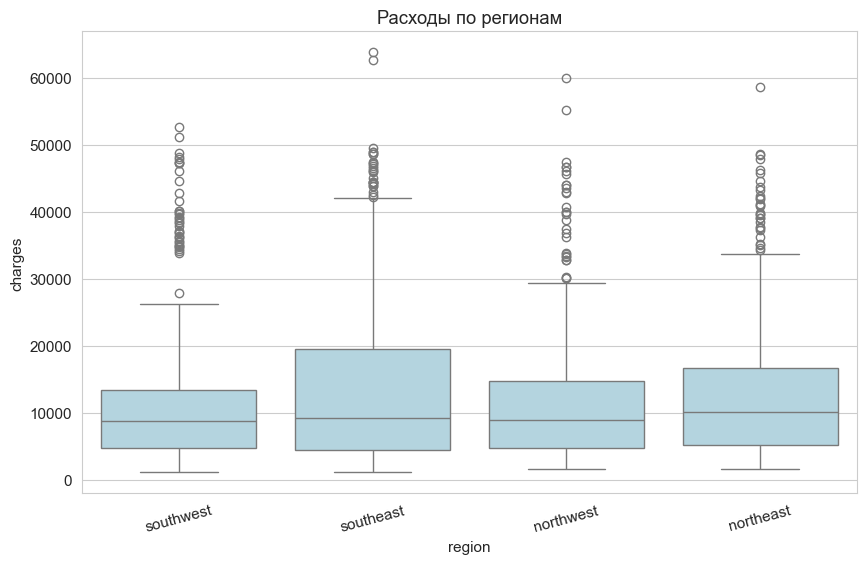

In [26]:

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

def one_way_anova(frame, y_name, factor):
    grouped = list(frame.groupby(factor, observed=True)[y_name])
    labels = [str(name) for name, _ in grouped]
    samples = [values.to_numpy() for _, values in grouped]
    n = sum(len(s) for s in samples)
    l = len(samples)
    grand = np.concatenate(samples).mean()
    Q = sum(((s - grand) ** 2).sum() for s in samples)
    Q1 = sum(len(s) * (s.mean() - grand) ** 2 for s in samples)
    Q2 = Q - Q1
    d1, d2 = l - 1, n - l
    F = (Q1 / d1) / (Q2 / d2)
    Fcrit = stats.f.ppf(0.95, d1, d2)
    p = stats.f.sf(F, d1, d2)  # survival function точнее, чем 1 − CDF
    print(f"Градаций l = {l}, объём n = {n}")
    print(f"{'Градация':<16} {'n':>8} {'среднее':>12} {'дисперсия':>12}")
    for label, sample in zip(labels, samples):
        print(f"{label:<16} {len(sample):8d} {sample.mean():12.3f} {sample.var(ddof=1):12.3f}")
    print(f"Q = {Q:.3f}, Q1 (между группами) = {Q1:.3f}, Q2 (внутри) = {Q2:.3f}")
    print(f"Q1 + Q2 = {Q1 + Q2:.3f}")
    print(f"F = (Q1/{d1}) / (Q2/{d2}) = {F:.3f}")
    print(f"F_крит(0.95; {d1}, {d2}) = {Fcrit:.3f}, p = {fmt_p(p)}")
    if F > Fcrit:
        print("H0 отвергается: средние градаций различаются, фактор влияет на отклик.")
    else:
        print("H0 не отвергается: влияние фактора не обнаружено.")
    W, p_lev = stats.levene(*samples, center="median")
    print(f"Левена (равенство дисперсий): W = {W:.3f}, p = {fmt_p(p_lev)}")
    if p_lev < 0.05:
        print("Дисперсии групп различаются, условие однородности дисперсий не выполнено.")
    else:
        print("Дисперсии групп можно считать равными.")
    H, p_kw = stats.kruskal(*samples)
    chi_crit = stats.chi2.ppf(0.95, d1)
    print(f"Краскел–Уоллис: H = {H:.3f}, χ²_крит(0.95, df={d1}) = {chi_crit:.3f}, p = {fmt_p(p_kw)}")
    if H > chi_crit:
        print("H0 Краскела–Уоллиса отвергается: распределения градаций различаются.")
    else:
        print("H0 Краскела–Уоллиса не отвергается.")
    return labels, samples

def two_way(frame, y_name, formula, factor_a, factor_b):
    counts = pd.crosstab(frame[factor_a], frame[factor_b])
    print("Число наблюдений в ячейках:")
    display(counts)
    n_min, n_max = counts.to_numpy().min(), counts.to_numpy().max()
    if n_min == n_max:
        print("Комплекс сбалансирован: в ячейках поровну наблюдений.")
    else:
        print(f"Комплекс не сбалансирован (от {n_min} до {n_max}). Считаем Type II ANOVA.")
    model = ols(formula, data=frame).fit()
    table = sm.stats.anova_lm(model, typ=2)
    dfd = table.loc["Residual", "df"]
    print(f"\n{'Источник':<40} {'SS':>14} {'df':>8} {'F':>10} {'F_крит':>10} {'p':>12}")
    for name, row in table.iterrows():
        if name == "Residual":
            print(f"{'Остаток':<40} {row['sum_sq']:14.1f} {row['df']:8.0f}")
            continue
        fcrit = stats.f.ppf(0.95, row["df"], dfd)
        verdict = "влияет" if row["F"] > fcrit else "не влияет"
        print(f"{name:<40} {row['sum_sq']:14.1f} {row['df']:8.0f} {row['F']:10.2f} {fcrit:10.3f} {fmt_p(row['PR(>F)']):>12}  {verdict}")
    return model

print("Однофакторный ANOVA. H0: средние расходы в четырёх регионах равны.")
print("H1: хотя бы два региона различаются. α = 0.05.")
one_way_anova(df, "charges", "region")
sns.boxplot(data=df, x="region", y="charges", color="lightblue")
plt.title("Расходы по регионам")
plt.xticks(rotation=15)
plt.show()
means = df.groupby("region")["charges"].mean().sort_values()
print("Средние:", ", ".join(f"{k} {v:.0f}" for k, v in means.items()))
print(f"Минимум в {means.index[0]} ({means.iloc[0]:.0f}), максимум в {means.index[-1]} ({means.iloc[-1]:.0f}).")
print("Фишер отвергает равенство средних (F = 2.97), Краскел–Уоллис — нет (H = 4.73 < 7.81, p = 0.19).")
print("Отклик не нормален и дисперсии регионов различаются, поэтому вывод по Краскелу–Уоллису: регион сам по себе распределение расходов не меняет.")


H0: курение не влияет; регион не влияет; взаимодействия нет. α = 0.05.
Число наблюдений в ячейках:


region,northeast,northwest,southeast,southwest
smoker,,,,
no,257,267,273,267
yes,67,58,91,58


Комплекс не сбалансирован (от 58 до 273). Считаем Type II ANOVA.

Источник                                             SS       df          F     F_крит            p
C(smoker)                                120326667100.4        1    2191.34      3.848  1.7519e-283  влияет
C(region)                                   107523160.0        3       0.65      2.612   5.8128e-01  не влияет
C(smoker):C(region)                        1416291755.9        3       8.60      2.612   1.1816e-05  влияет
Остаток                                   73030503030.8     1330
Курение влияет: F = 2191 при F_крит = 3.85. Регион при учёте курения не влияет (F = 0.65 < 2.61).
Взаимодействие значимо (F = 8.60): региональный разрыв расходов зависит от того, курит человек или нет.
Однофакторный вывод по региону берём у Краскела–Уоллиса, а не у Фишера: нормальность расходов нарушена.


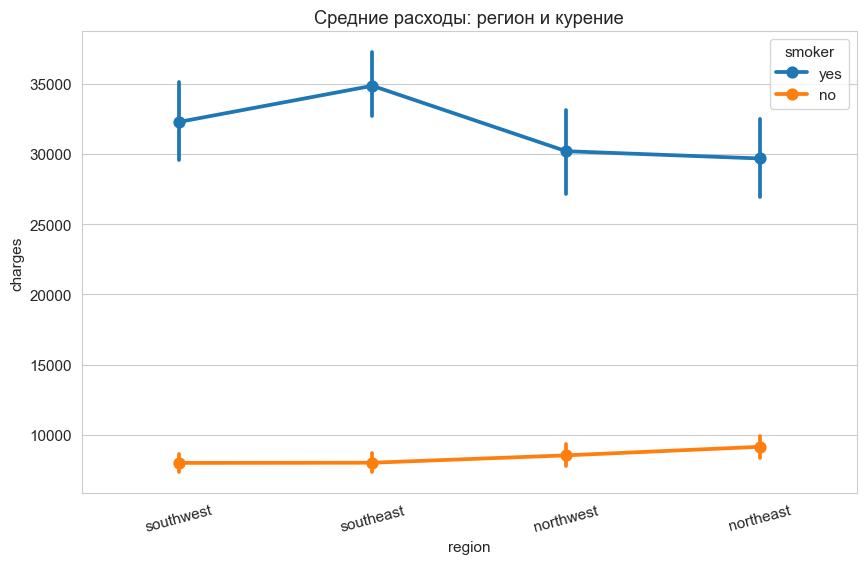

In [27]:
# 10. Двухфакторный анализ: курение и регион
print("H0: курение не влияет; регион не влияет; взаимодействия нет. α = 0.05.")
two_way(
    df, "charges",
    "charges ~ C(smoker) + C(region) + C(smoker):C(region)",
    "smoker", "region",
)
sns.pointplot(data=df, x="region", y="charges", hue="smoker", errorbar=("ci", 95))
plt.title("Средние расходы: регион и курение")
plt.xticks(rotation=15)
plt.show()
print("Курение влияет: F = 2191 при F_крит = 3.85. Регион при учёте курения не влияет (F = 0.65 < 2.61).")
print("Взаимодействие значимо (F = 8.60): региональный разрыв расходов зависит от того, курит человек или нет.")
print("Однофакторный вывод по региону берём у Краскела–Уоллиса, а не у Фишера: нормальность расходов нарушена.")
